# Notebook 02: Advanced EDA & Statistical Analysis

## Project: Indian Air Quality Index (AQI) Comprehensive Analysis
## BTech Final Year Project - Data Science & Machine Learning (8th Semester)

### Objective:
Perform advanced exploratory data analysis including correlation analysis, temporal patterns, seasonal trends, and comprehensive statistical testing.

### Prerequisites:
- Complete Notebook 01 first (generates city_day_cleaned.csv)
- Libraries: pandas, numpy, matplotlib, seaborn, scipy, statsmodels

### Run Time: 10-15 minutes

## Step 1: Import Libraries & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
from scipy.stats import shapiro, kstest, mannwhitneyu, kruskal
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
print('Libraries imported!')

Libraries imported!


### Explanation:

- **from scipy import stats**: SciPy is a scientific computing library. Stats module provides statistical tests and distributions.

- **from scipy.stats import shapiro**: Shapiro-Wilk test for checking if data follows normal distribution.

- **from scipy.stats import kstest**: Kolmogorov-Smirnov test for comparing distributions.

- **from scipy.stats import mannwhitneyu**: Mann-Whitney U test for comparing two independent groups.

- **from scipy.stats import kruskal**: Kruskal-Wallis test for comparing three or more groups (non-parametric ANOVA).

In [2]:
data_path = os.path.join('..', 'datasets', 'city_day_cleaned.csv')
df = pd.read_csv(data_path, parse_dates=['Datetime'])
print(f'Loaded cleaned data: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Date range: {df["Datetime"].min()} to {df["Datetime"].max()}')

Loaded cleaned data: 442985 rows, 18 columns
Date range: 2015-01-01 00:00:00 to 2025-07-31 00:00:00


### Explanation:

- **parse_dates=['Datetime']**: Tells pandas to automatically parse the Datetime column as datetime objects during loading.

## Step 2: Extract Time Features

In [3]:
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day
df['DayOfWeek'] = df['Datetime'].dt.dayofweek
df['Quarter'] = df['Datetime'].dt.quarter
df['Season'] = df['Month'].map({12:'Winter', 1:'Winter', 2:'Winter',
                                 3:'Summer', 4:'Summer', 5:'Summer',
                                 6:'Monsoon', 7:'Monsoon', 8:'Monsoon',
                                 9:'Post-Monsoon', 10:'Post-Monsoon', 11:'Post-Monsoon'})
print('Time features extracted!')
print(df[['Datetime', 'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'Season']].head())

Time features extracted!
    Datetime  Year  Month  Day  DayOfWeek  Quarter        Season
0 2020-11-09  2020     11    9          0        4  Post-Monsoon
1 2020-11-10  2020     11   10          1        4  Post-Monsoon
2 2020-11-11  2020     11   11          2        4  Post-Monsoon
3 2020-11-12  2020     11   12          3        4  Post-Monsoon
4 2020-11-13  2020     11   13          4        4  Post-Monsoon


### Explanation:

- **df['Datetime'].dt.year**: Extracts the year component from datetime (e.g., 2020).

- **df['Datetime'].dt.month**: Extracts month (1-12).

- **df['Datetime'].dt.day**: Extracts day of month (1-31).

- **df['Datetime'].dt.dayofweek**: Extracts day of week (0=Monday, 6=Sunday).

- **df['Datetime'].dt.quarter**: Extracts quarter (1-4).

- **.map()**: Replaces values using a dictionary mapping. We map month numbers to season names.

## Step 3: Correlation Analysis - Pearson Correlation Matrix

In [4]:
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI']
corr_matrix = df[pollutants].corr(method='pearson')
print('Pearson Correlation Matrix:')
corr_matrix.round(2)

Pearson Correlation Matrix:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI
PM2.5,1.00,0.56,0.43,0.34,0.38,0.19,0.09,0.12,0.16,0.78
PM10,0.56,1.00,0.43,0.36,0.42,0.22,0.05,0.18,0.20,0.61
NO,0.43,0.43,1.00,0.46,0.75,0.16,0.21,0.17,0.01,0.42
NO2,0.34,0.36,0.46,1.00,0.57,0.17,0.35,0.38,0.29,0.39
NOx,0.38,0.42,0.75,0.57,1.00,0.13,0.23,0.21,0.08,0.42
NH3,0.19,0.22,0.16,0.17,0.13,1.00,0.02,-0.02,0.08,0.17
CO,0.09,0.05,0.21,0.35,0.23,0.02,1.00,0.47,0.04,0.19
SO2,0.12,0.18,0.17,0.38,0.21,-0.02,0.47,1.00,0.16,0.21
O3,0.16,0.20,0.01,0.29,0.08,0.08,0.04,0.16,1.00,0.22
AQI,0.78,0.61,0.42,0.39,0.42,0.17,0.19,0.21,0.22,1.00


### Explanation:

- **df[pollutants].corr()**: Calculates correlation coefficients between all pollutant pairs.

- **method='pearson'**: Pearson correlation measures linear relationship (-1 to +1). +1 means perfect positive correlation, -1 means perfect negative correlation, 0 means no correlation.

- **.round(2)**: Rounds values to 2 decimal places for readability.

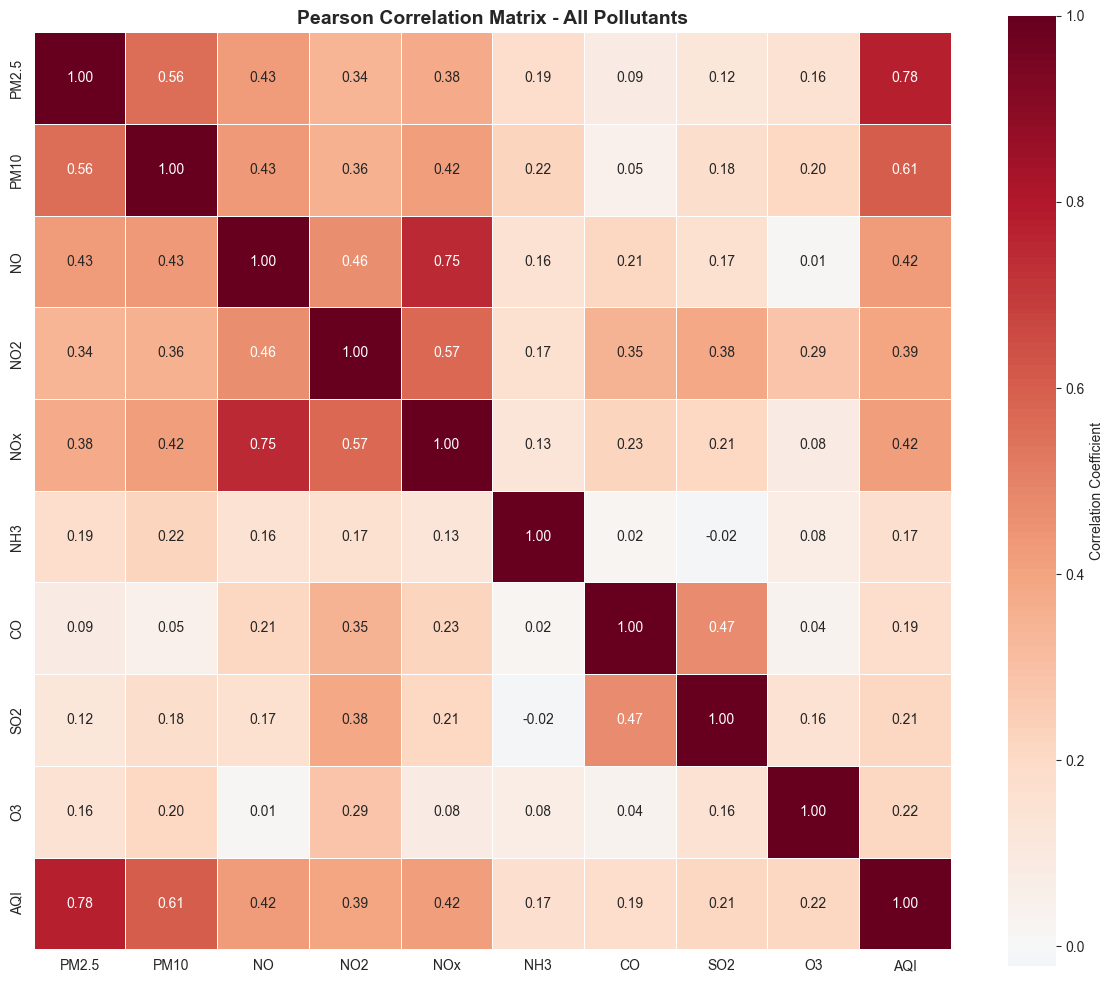

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            linewidths=0.5, square=True, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Pearson Correlation Matrix - All Pollutants', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Explanation:

- **sns.heatmap()**: Creates a color-coded matrix visualization where colors represent correlation values.

- **annot=True**: Displays correlation values on the heatmap cells.

- **cmap='RdBu_r'**: Uses Red-Blue diverging colormap (reversed). Red=positive correlation, Blue=negative correlation.

- **center=0**: Centers the colormap at 0 to show positive and negative correlations equally.

- **fmt='.2f'**: Formats annotation values to 2 decimal places.

- **linewidths=0.5**: Adds thin lines between cells for better separation.

- **square=True**: Makes each cell square-shaped for better aesthetics.

## Step 4: Spearman Correlation (Non-linear Relationships)

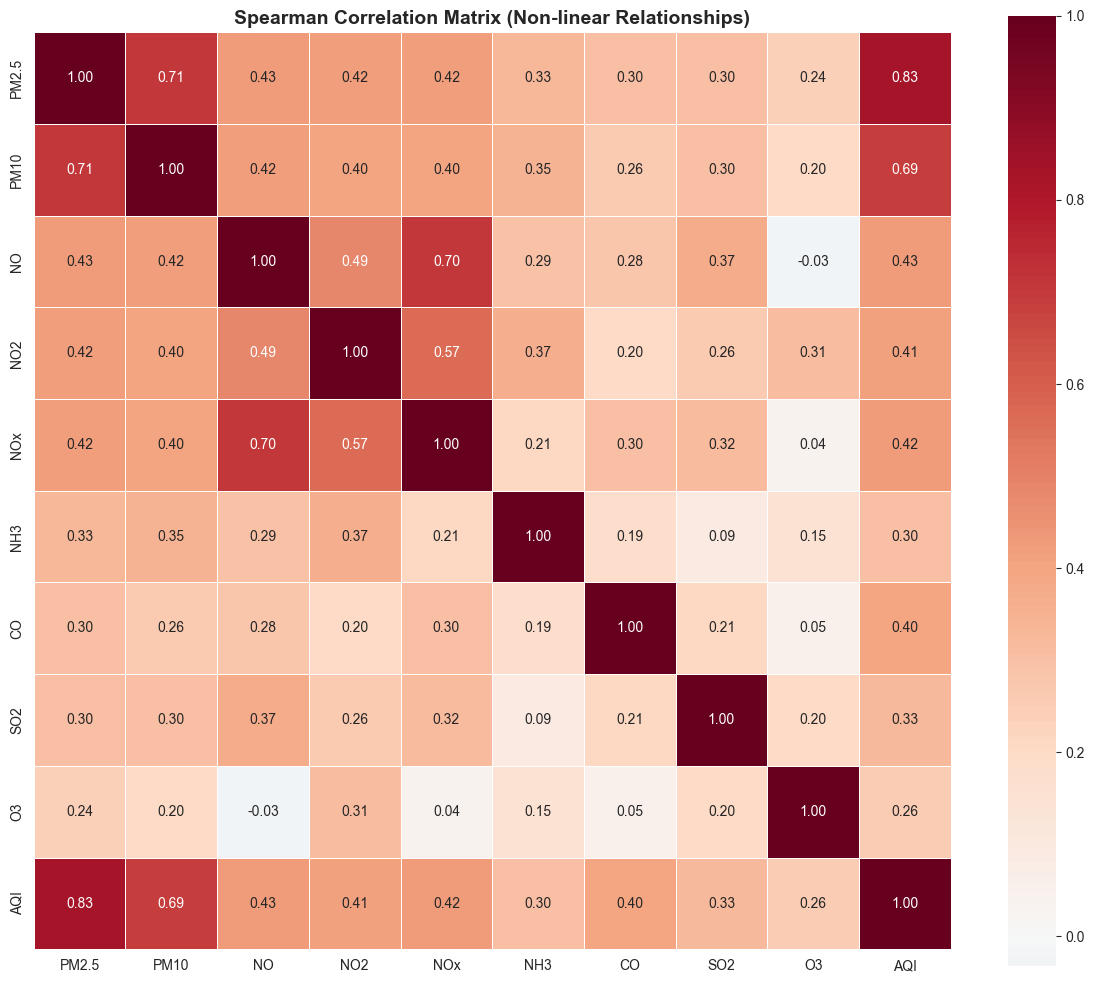

In [6]:
spearman_corr = df[pollutants].corr(method='spearman')
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Spearman Correlation Matrix (Non-linear Relationships)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Explanation:

- **method='spearman'**: Spearman correlation measures monotonic relationships (not just linear). Better for non-linear but consistently increasing/decreasing relationships.

## Step 5: Yearly Trends Analysis

In [7]:
yearly_trends = df.groupby('Year').agg(
    AQI_Mean=('AQI', 'mean'),
    AQI_Median=('AQI', 'median'),
    PM25_Mean=('PM2.5', 'mean'),
    PM10_Mean=('PM10', 'mean'),
    Record_Count=('AQI', 'count')
).round(1)
print('Yearly Trends:')
yearly_trends

Yearly Trends:


,AQI_Mean,AQI_Median,PM25_Mean,PM10_Mean,Record_Count
Year,,,,,
2015,171.7,166.5,78.0,130.5,4271
2016,159.4,129.0,86.3,127.2,8279
2017,153.7,127.0,80.5,122.9,13063
2018,147.5,122.0,69.0,128.1,22411
2019,136.5,111.0,59.3,113.9,34952
2020,113.6,88.0,44.8,92.0,40970
2021,120.5,93.0,NaN,NaN,48001
2022,121.3,97.0,NaN,NaN,57872
2023,114.5,93.0,NaN,NaN,78130


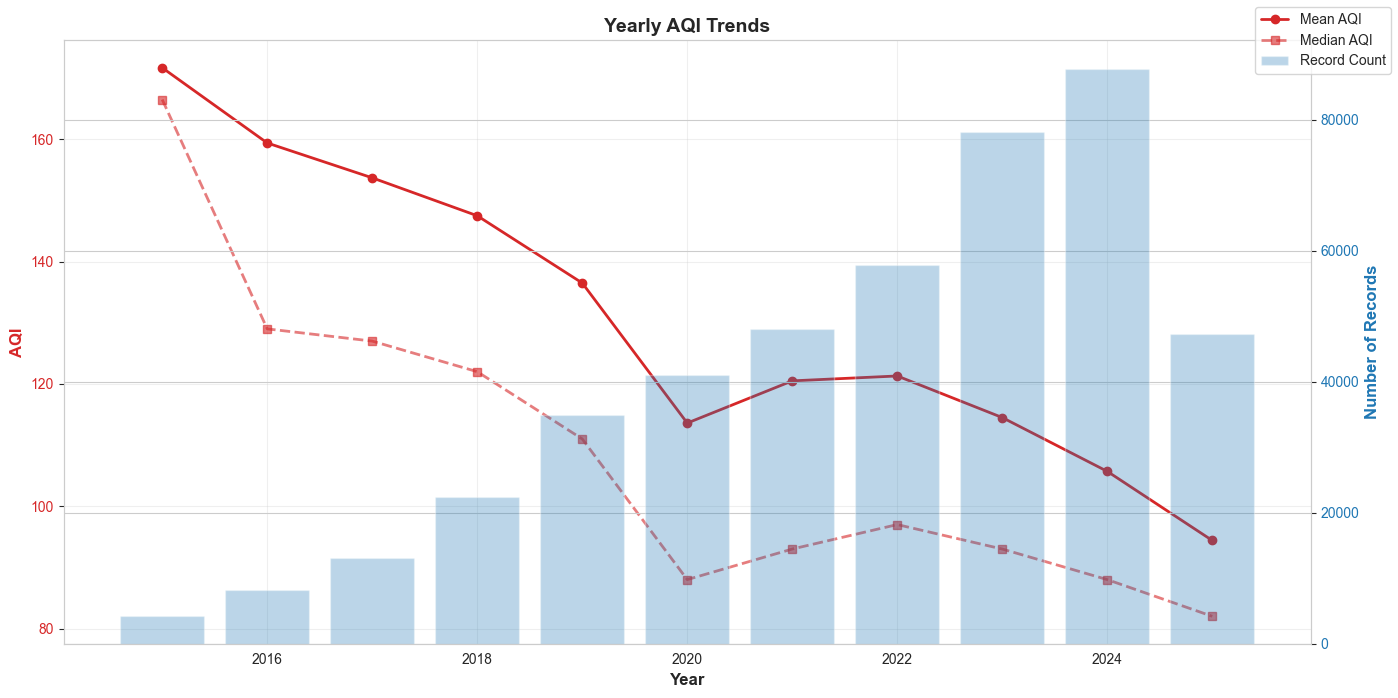

In [8]:
fig, ax1 = plt.subplots(figsize=(14, 7))
color1, color2 = 'tab:red', 'tab:blue'
ax1.plot(yearly_trends.index, yearly_trends['AQI_Mean'], marker='o', linewidth=2, color=color1, label='Mean AQI')
ax1.plot(yearly_trends.index, yearly_trends['AQI_Median'], marker='s', linestyle='--', linewidth=2, color=color1, alpha=0.6, label='Median AQI')
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('AQI', fontsize=12, fontweight='bold', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.bar(yearly_trends.index, yearly_trends['Record_Count'], alpha=0.3, color=color2, label='Record Count')
ax2.set_ylabel('Number of Records', fontsize=12, fontweight='bold', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
plt.title('Yearly AQI Trends', fontsize=14, fontweight='bold')
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Explanation:

- **fig, ax1 = plt.subplots()**: Creates figure and primary axis object.

- **ax1.twinx()**: Creates a secondary y-axis that shares the same x-axis (allows plotting two different scales).

- **ax1.plot()**: Creates line plot for AQI trends over years.

- **marker='o'**: Adds circle markers at data points.

- **linestyle='--'**: Creates dashed line style.

- **alpha=0.6**: Sets transparency (0=transparent, 1=opaque).

- **ax1.tick_params()**: Customizes axis tick mark appearance.

## Step 6: Monthly Seasonal Patterns

In [9]:
monthly_patterns = df.groupby('Month').agg(
    AQI_Mean=('AQI', 'mean'),
    AQI_Std=('AQI', 'std'),
    PM25_Mean=('PM2.5', 'mean'),
    PM10_Mean=('PM10', 'mean')
).round(1)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_patterns.index = month_names
print('Monthly Patterns:')
monthly_patterns

Monthly Patterns:


,AQI_Mean,AQI_Std,PM25_Mean,PM10_Mean
Jan,163.4,92.7,100.3,148.5
Feb,138.8,74.0,80.5,137.8
Mar,122.3,63.4,64.4,117.2
Apr,118.1,64.6,54.8,110.2
May,108.0,62.7,53.6,109.8
Jun,92.8,58.5,47.4,97.9
Jul,66.4,40.1,42.6,91.7
Aug,67.1,37.0,40.2,91.2
Sep,71.2,40.4,43.8,93.1
Oct,121.3,77.1,73.6,122.3


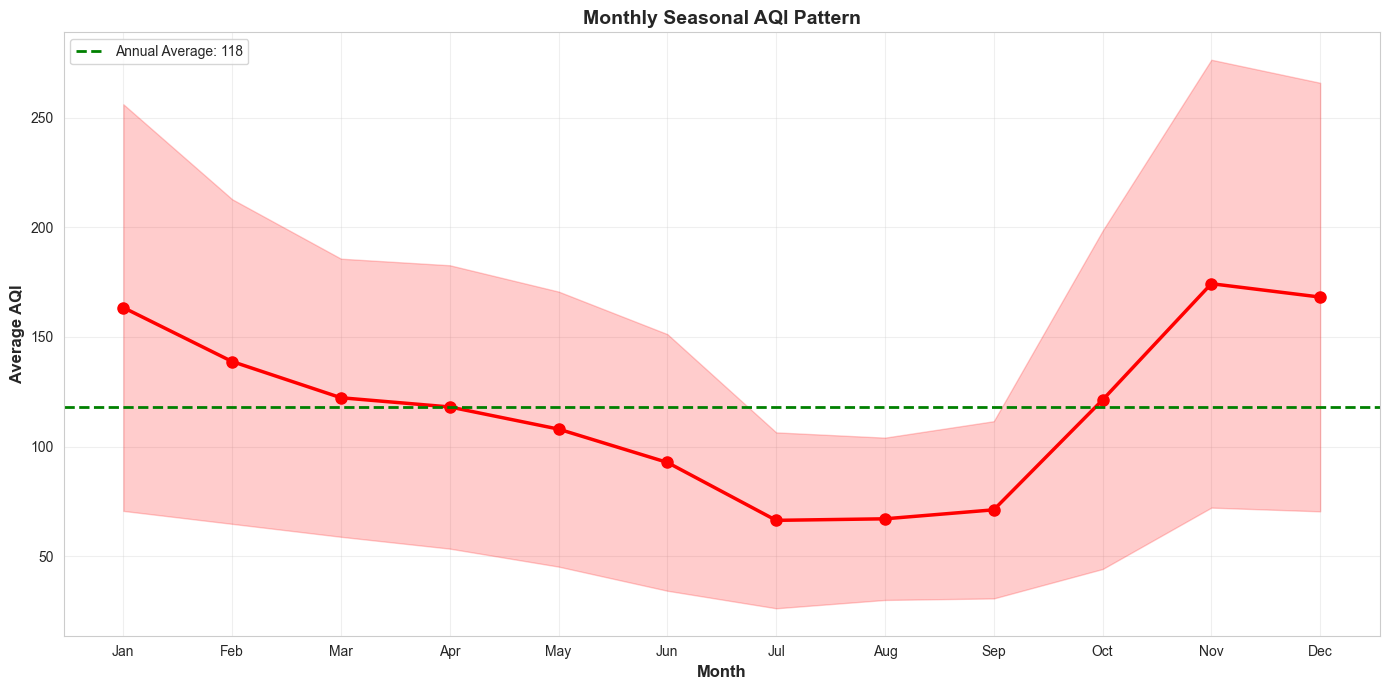

In [10]:
plt.figure(figsize=(14, 7))
plt.plot(month_names, monthly_patterns['AQI_Mean'], marker='o', linewidth=2.5, markersize=8, color='red')
plt.fill_between(range(12), 
                  monthly_patterns['AQI_Mean'] - monthly_patterns['AQI_Std'],
                  monthly_patterns['AQI_Mean'] + monthly_patterns['AQI_Std'],
                  alpha=0.2, color='red')
plt.axhline(df['AQI'].mean(), color='green', linestyle='--', linewidth=2, label=f'Annual Average: {df["AQI"].mean():.0f}')
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Average AQI', fontsize=12, fontweight='bold')
plt.title('Monthly Seasonal AQI Pattern', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Explanation:

- **plt.fill_between()**: Creates a shaded region between two lines (shows standard deviation range).

- **plt.axhline()**: Draws a horizontal line at the annual average AQI for comparison.

- **markersize=8**: Controls the size of marker points on the line.

## Step 7: Seasonal Comparison (Box Plot)

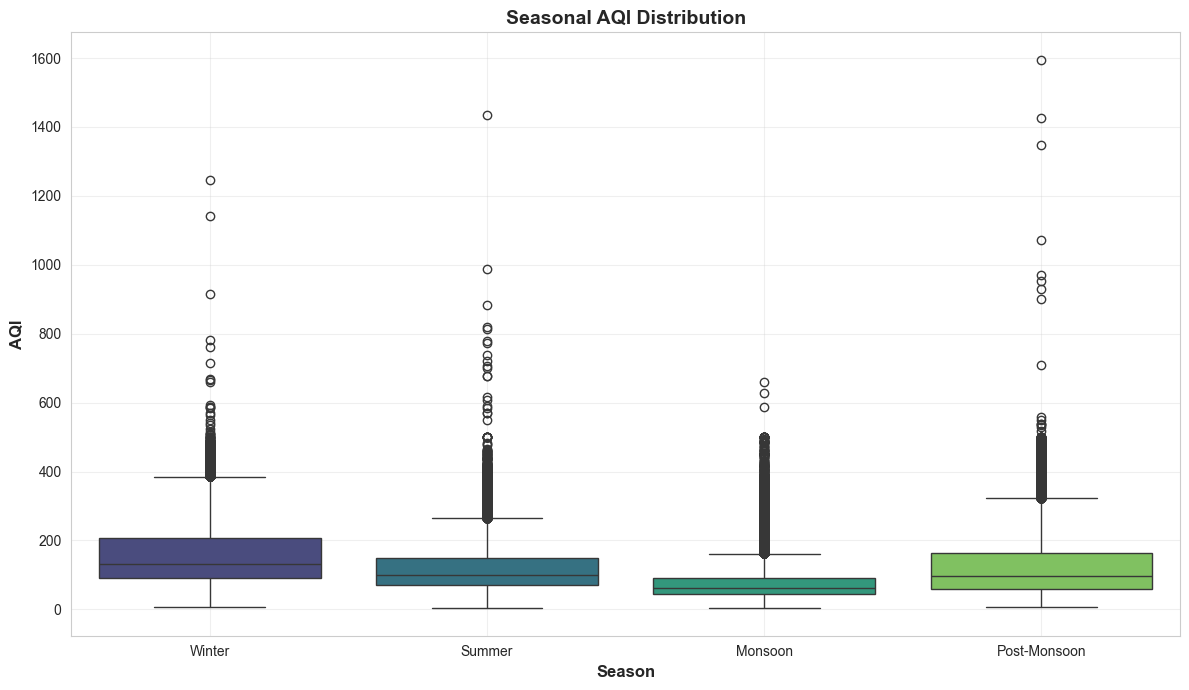

In [11]:
season_order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='Season', y='AQI', order=season_order, palette='viridis')
plt.xlabel('Season', fontsize=12, fontweight='bold')
plt.ylabel('AQI', fontsize=12, fontweight='bold')
plt.title('Seasonal AQI Distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Explanation:

- **sns.boxplot()**: Creates box plot showing median, quartiles, and outliers for each season.

- **order=season_order**: Specifies the order of categories on x-axis.

- **palette='viridis'**: Uses viridis colormap (perceptually uniform, colorblind-friendly).

## Step 8: Top 10 Most Polluted Cities

In [12]:
city_pollution = df.groupby('City').agg(
    AQI_Mean=('AQI', 'mean'),
    AQI_Max=('AQI', 'max'),
    PM25_Mean=('PM2.5', 'mean'),
    Days_Recorded=('AQI', 'count')
).sort_values('AQI_Mean', ascending=False).head(10)
print('Top 10 Most Polluted Cities:')
city_pollution.round(1)

Top 10 Most Polluted Cities:


,AQI_Mean,AQI_Max,PM25_Mean,Days_Recorded
City,,,,
Loni_Ghaziabad,336.5,358.0,NaN,2
Loni Ghaziabad,336.5,358.0,NaN,2
Jharsuguda,282.0,282.0,NaN,1
Byrnihat,230.8,442.0,NaN,724
Delhi,217.4,497.0,117.1,3864
Ghaziabad,211.5,500.0,NaN,2995
Darbhanga,207.7,473.0,NaN,407
Greater Noida,204.8,500.0,NaN,2611
Bhiwadi,203.9,483.0,NaN,2634


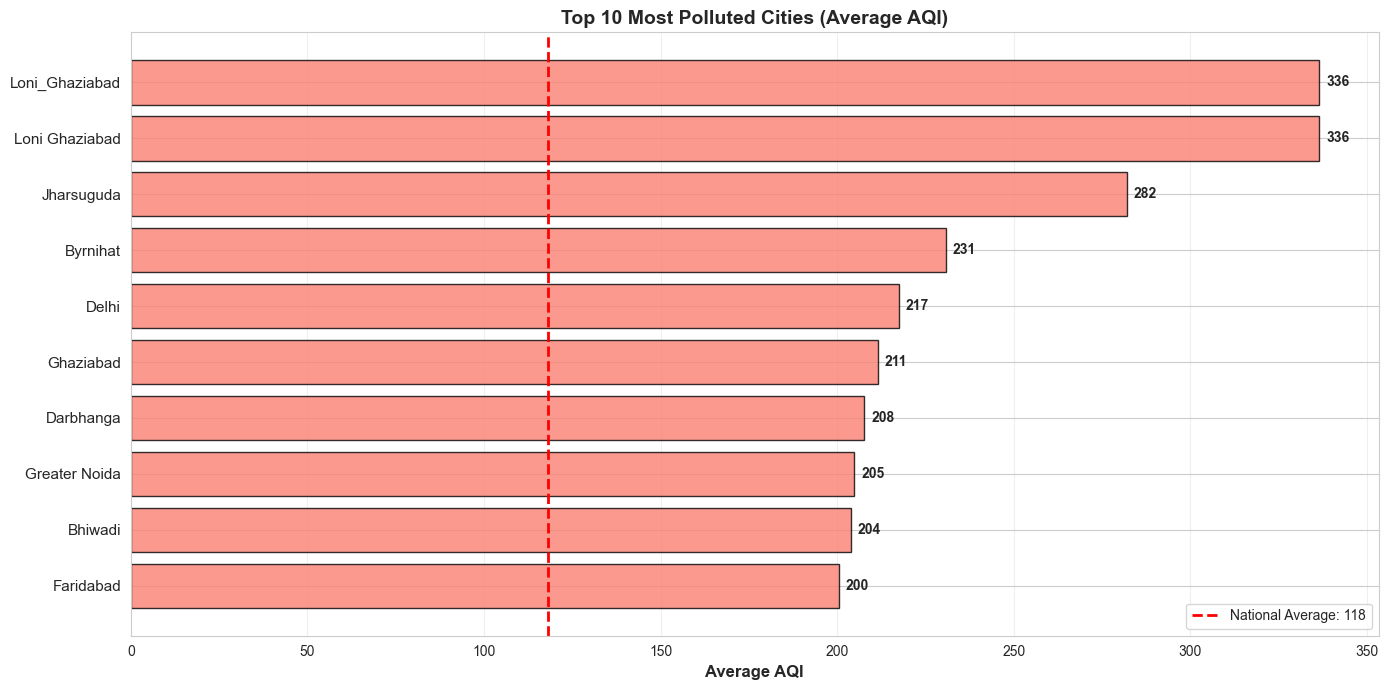

In [13]:
plt.figure(figsize=(14, 7))
bars = plt.barh(range(10), city_pollution['AQI_Mean'].values[::-1], 
                color='salmon', edgecolor='black', alpha=0.8)
plt.yticks(range(10), city_pollution.index[::-1], fontsize=11)
plt.xlabel('Average AQI', fontsize=12, fontweight='bold')
plt.title('Top 10 Most Polluted Cities (Average AQI)', fontsize=14, fontweight='bold')
for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f'{city_pollution["AQI_Mean"].values[::-1][i]:.0f}', 
             va='center', fontsize=10, fontweight='bold')
plt.axvline(df['AQI'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'National Average: {df["AQI"].mean():.0f}')
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Explanation:

- **plt.barh()**: Creates horizontal bar chart (better for city names).

- **range(10)**: Creates y-axis positions (0 to 9) for 10 bars.

- **plt.yticks()**: Sets custom labels for y-axis positions.

- **values[::-1]**: Reverses array to display highest values at top.

## Step 9: Pollutant Distribution (Violin Plot)

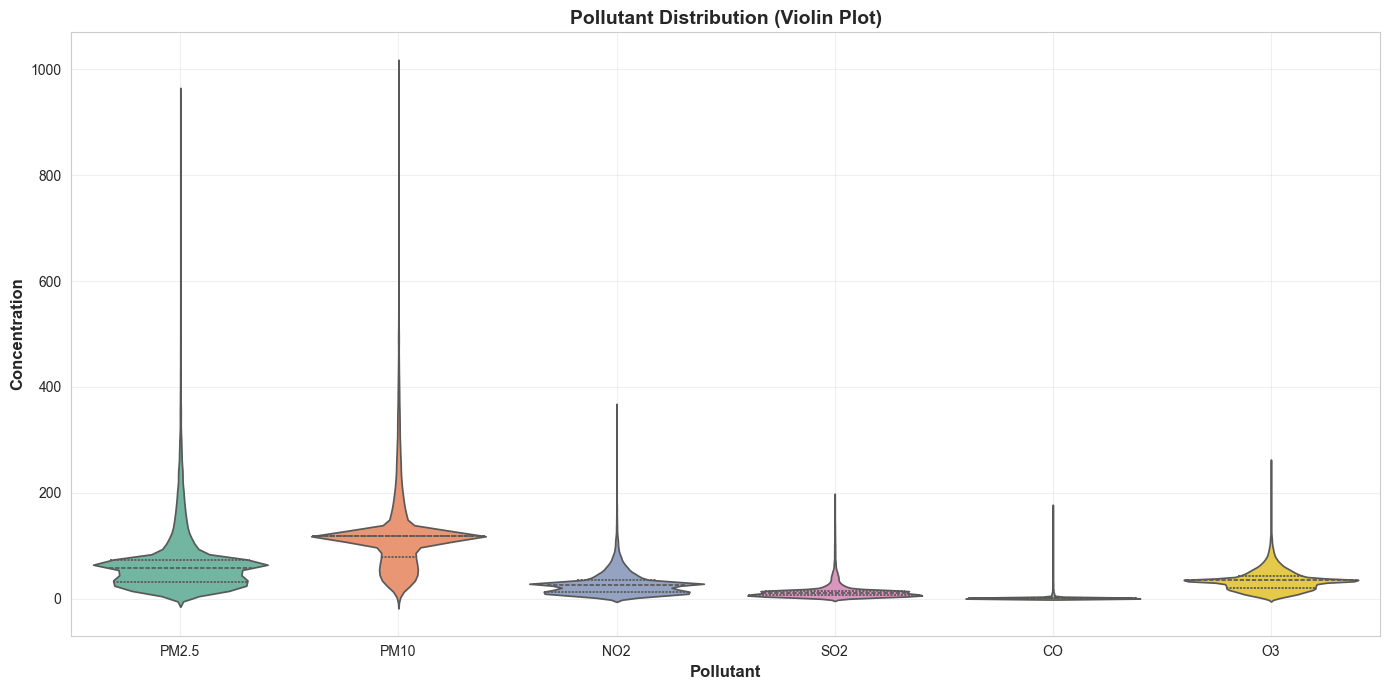

In [14]:
pollutant_data = df[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']].melt(var_name='Pollutant', value_name='Concentration')
plt.figure(figsize=(14, 7))
sns.violinplot(data=pollutant_data, x='Pollutant', y='Concentration', palette='Set2', inner='quartile')
plt.xlabel('Pollutant', fontsize=12, fontweight='bold')
plt.ylabel('Concentration', fontsize=12, fontweight='bold')
plt.title('Pollutant Distribution (Violin Plot)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Explanation:

- **.melt()**: Converts wide format DataFrame to long format (unpivots columns to rows).

- **var_name='Pollutant'**: Names the column that holds original column names.

- **value_name='Concentration'**: Names the column that holds the values.

- **sns.violinplot()**: Creates violin plot showing distribution shape (wider = more data points).

- **inner='quartile'**: Shows quartile lines inside the violin (25%, 50%, 75%).

## Step 10: AQI Category Transitions

In [15]:
bucket_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
bucket_counts_by_year = df.groupby(['Year', 'AQI_Bucket']).size().unstack(fill_value=0)
bucket_pcts = bucket_counts_by_year.div(bucket_counts_by_year.sum(axis=1), axis=0) * 100
bucket_pcts = bucket_pcts.reindex(columns=bucket_order, fill_value=0)
print('AQI Category Distribution by Year (%):')
bucket_pcts.round(1)

AQI Category Distribution by Year (%):


AQI_Bucket,Good,Satisfactory,Moderate,Poor,Very Poor,Severe
Year,,,,,,
2015,5.6,23.7,44.8,11.5,10.3,3.7
2016,9.8,25.4,38.5,13.4,9.1,3.9
2017,7.3,31.1,37.2,13.6,8.4,2.4
2018,6.9,30.4,40.4,13.6,7.1,1.5
2019,10.6,33.3,36.3,13.2,5.3,1.2
2020,19.6,37.8,28.9,9.4,3.6,0.7
2021,19.4,34.8,28.7,11.8,4.7,0.6
2022,17.7,34.4,31.3,12.0,4.1,0.5
2023,17.3,37.4,32.3,9.5,3.2,0.3


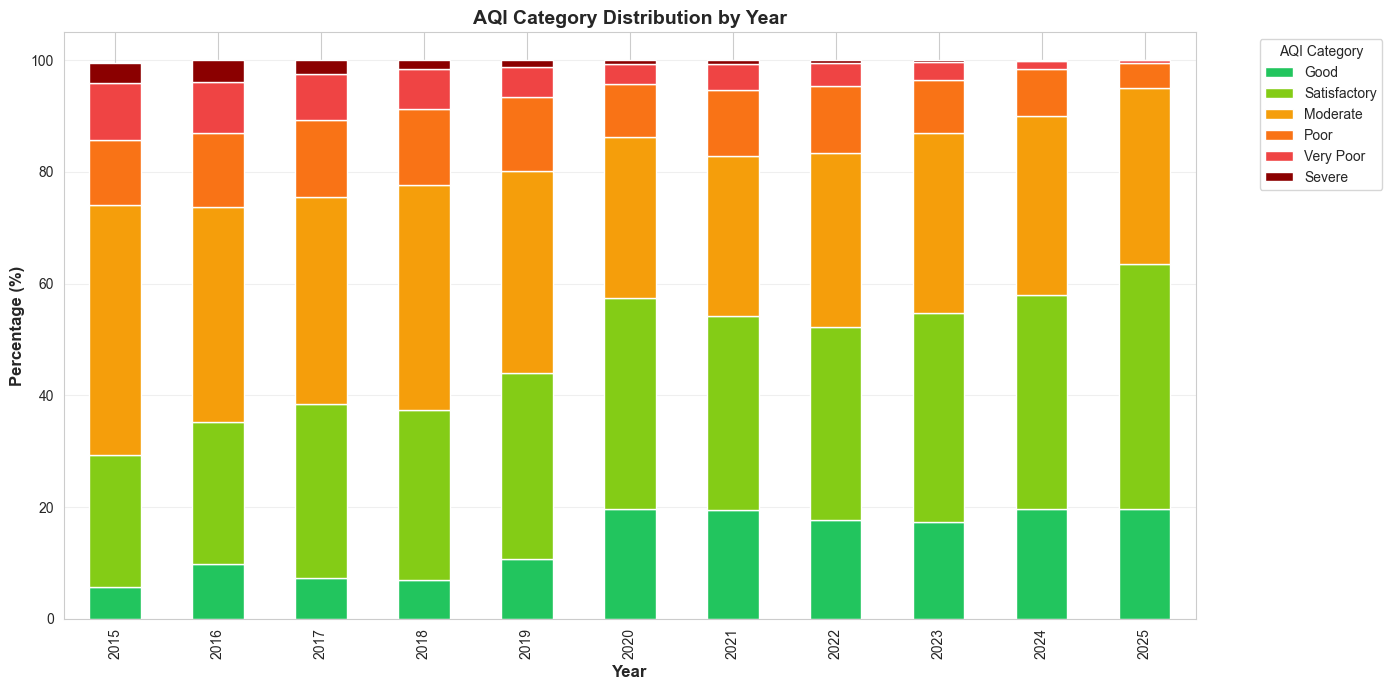

In [16]:
bucket_pcts.plot(kind='bar', stacked=True, figsize=(14, 7), 
                  color=['#22C55E', '#84CC16', '#F59E0B', '#F97316', '#EF4444', '#8B0000'])
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.title('AQI Category Distribution by Year', fontsize=14, fontweight='bold')
plt.legend(title='AQI Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Explanation:

- **.size()**: Counts number of rows in each group.

- **.unstack()**: Pivots a level of row index to columns (converts long to wide format).

- **.div(..., axis=0)**: Divides each row by row sum to get percentages.

- **.reindex()**: Reorders columns to match specified order, filling missing with 0.

- **kind='bar', stacked=True**: Creates stacked bar chart showing composition.

## Step 11: Pair Plot (Subset for Performance)

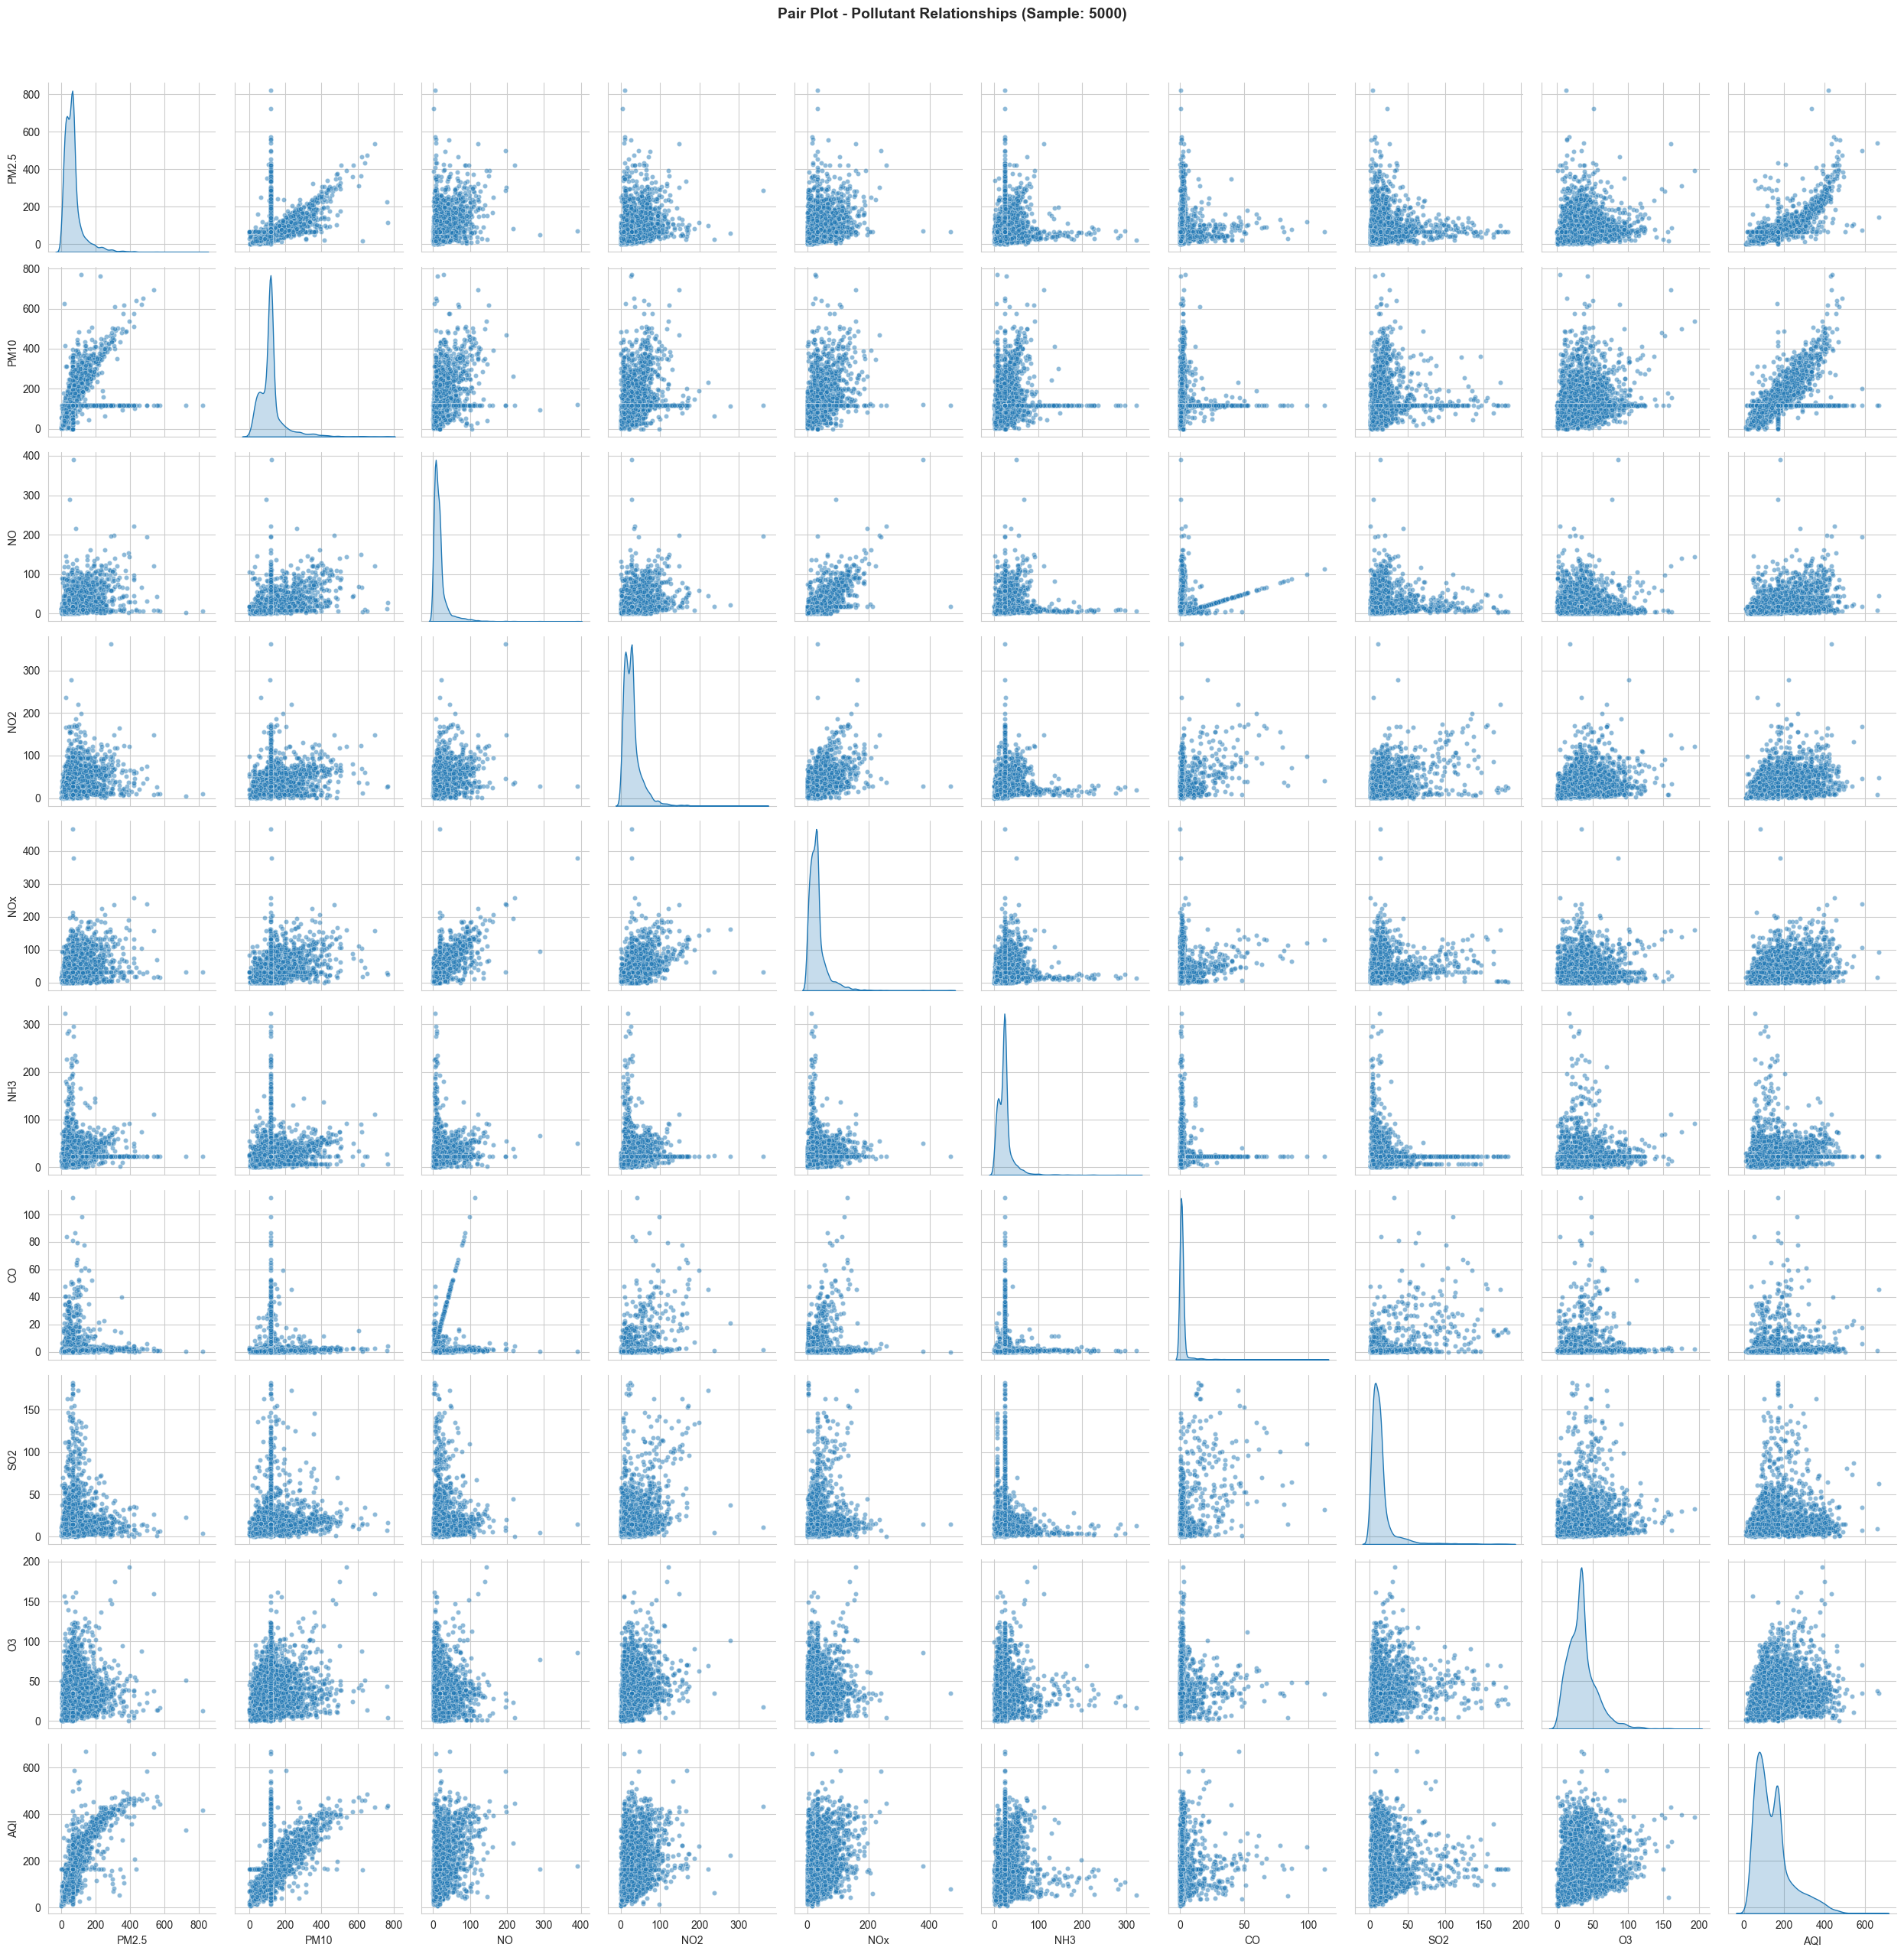

In [17]:
sample_data = df[pollutants].dropna().sample(n=5000, random_state=42)
pair_plot = sns.pairplot(sample_data, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
pair_plot.fig.suptitle('Pair Plot - Pollutant Relationships (Sample: 5000)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Explanation:

- **.sample(n=5000)**: Randomly samples 5000 rows for faster plotting (pair plots are computationally expensive).

- **random_state=42**: Sets seed for reproducible sampling (same sample every time).

- **sns.pairplot()**: Creates grid of scatter plots for all variable pairs.

- **diag_kind='kde'**: Shows kernel density estimate on diagonal instead of histogram.

- **plot_kws={'alpha': 0.5, 's': 20}**: Sets point transparency (alpha) and size (s).

## Step 12: Statistical Tests - Normality Test

In [18]:
print('Shapiro-Wilk Normality Test (p > 0.05 means normally distributed):')
for col in pollutants[:5]:
    clean_data = df[col].dropna()
    if len(clean_data) > 5000:
        clean_data = clean_data.sample(5000, random_state=42)
    stat, p_value = shapiro(clean_data)
    print(f'{col:8s}: Statistic={stat:.4f}, p-value={p_value:.6f} - {"Normal" if p_value > 0.05 else "Not Normal"}')

Shapiro-Wilk Normality Test (p > 0.05 means normally distributed):
PM2.5   : Statistic=0.6992, p-value=0.000000 - Not Normal
PM10    : Statistic=0.7515, p-value=0.000000 - Not Normal
NO      : Statistic=0.6116, p-value=0.000000 - Not Normal
NO2     : Statistic=0.7747, p-value=0.000000 - Not Normal
NOx     : Statistic=0.7469, p-value=0.000000 - Not Normal


### Explanation:

- **shapiro()**: Performs Shapiro-Wilk test for normality.

- **p_value > 0.05**: If p-value greater than 0.05, data is normally distributed (fail to reject null hypothesis).

- **p_value < 0.05**: Data is NOT normally distributed (reject null hypothesis).

- **len(clean_data) > 5000**: Shapiro test is slow for large datasets, so we sample 5000 points.

## Step 13: Kruskal-Wallis Test (Regional Differences)

In [19]:
regions = df['Region'].unique()
region_aqi_groups = [df[df['Region'] == r]['AQI'].dropna() for r in regions]
stat, p_value = kruskal(*region_aqi_groups)
print(f'Kruskal-Wallis Test - Regional AQI Differences:')
print(f'Statistic: {stat:.4f}')
print(f'p-value: {p_value:.6f}')
print(f'Result: {"Significant differences exist" if p_value < 0.05 else "No significant differences"}')

Kruskal-Wallis Test - Regional AQI Differences:
Statistic: nan
p-value: nan
Result: No significant differences


### Explanation:

- **kruskal()**: Kruskal-Wallis H test compares medians across 3+ groups (non-parametric ANOVA).

- ***region_aqi_groups**: Unpacks list into separate arguments (required by kruskal function).

- **p_value < 0.05**: Statistically significant difference exists between at least two regions.

## Step 14: Correlation Heatmap by Region

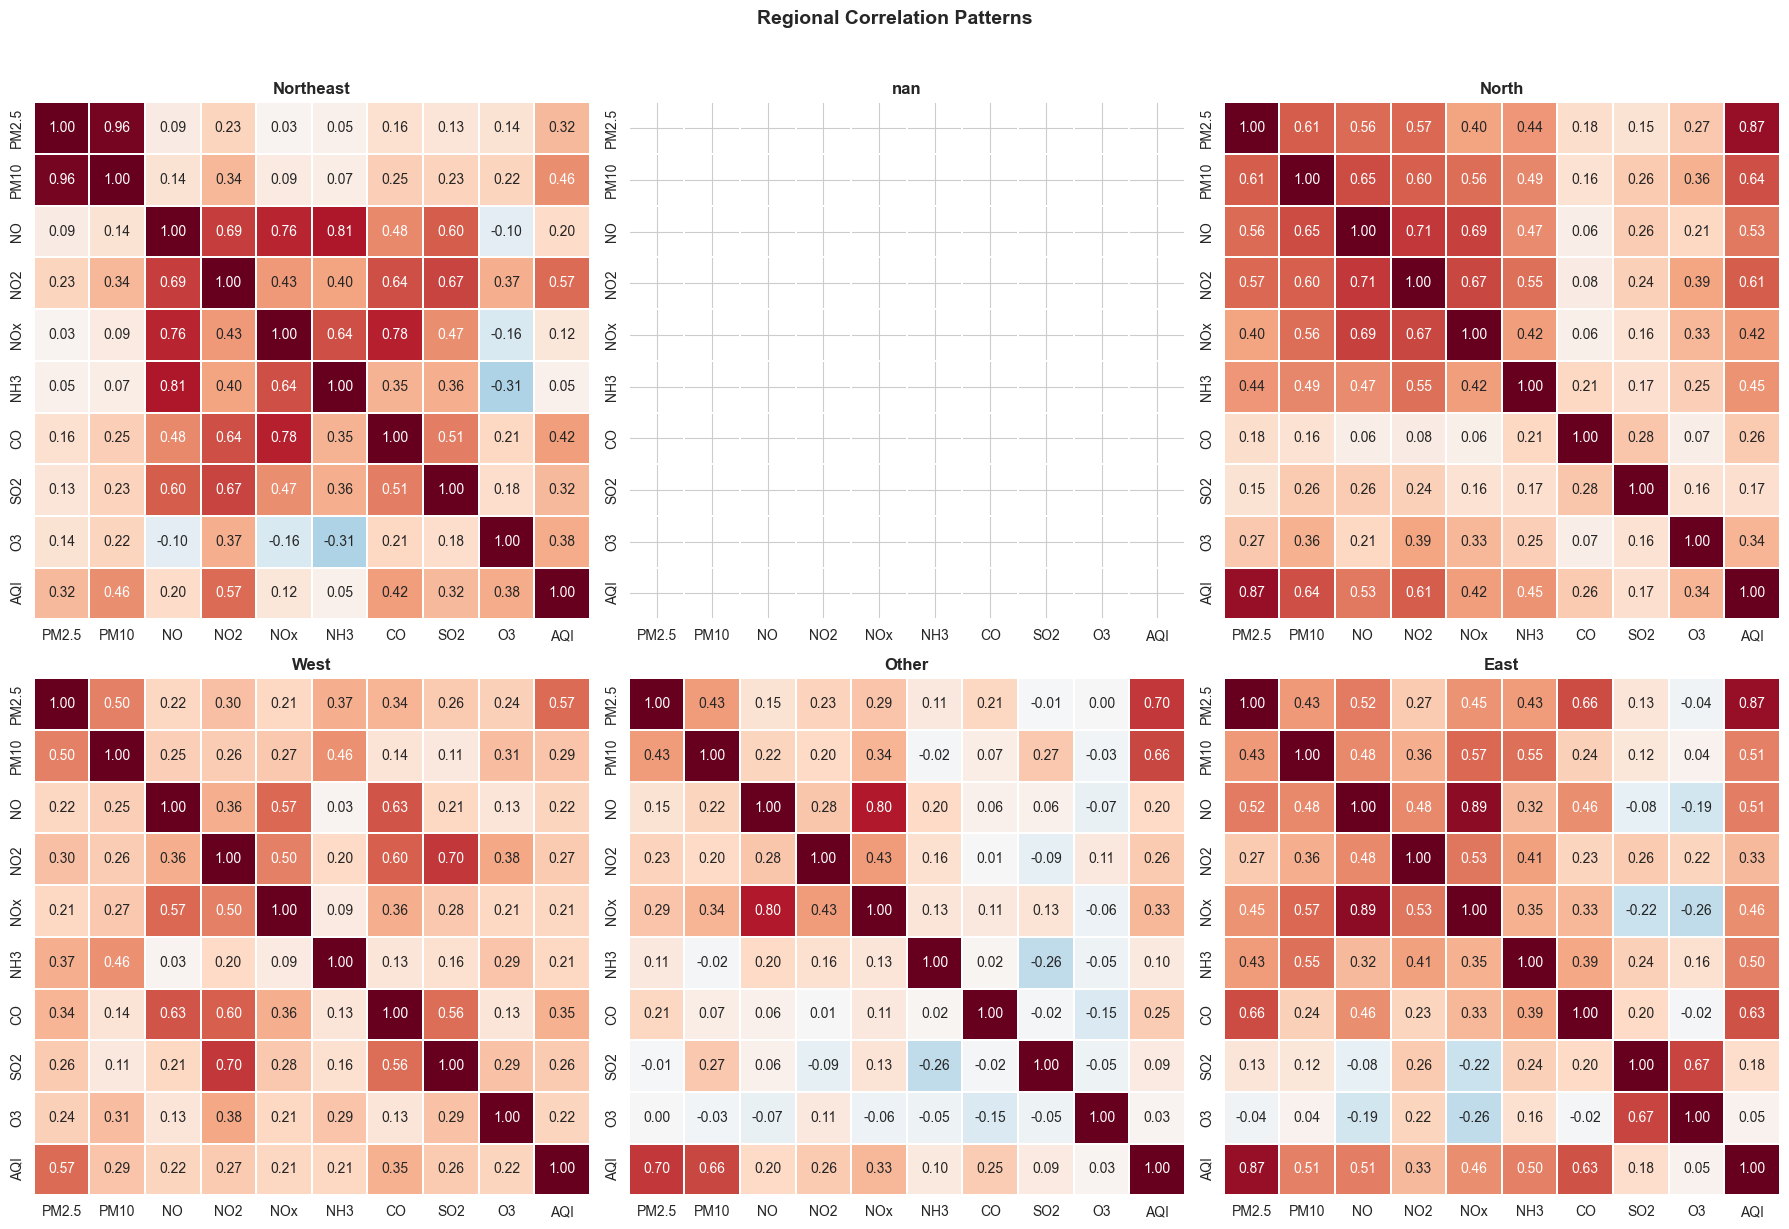

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for i, region in enumerate(regions):
    if i >= len(axes):
        break
    region_data = df[df['Region'] == region][pollutants].corr()
    sns.heatmap(region_data, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
                ax=axes[i], cbar=False, linewidths=0.3)
    axes[i].set_title(f'{region}', fontsize=12, fontweight='bold')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Regional Correlation Patterns', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Explanation:

- **plt.subplots(2, 3)**: Creates 2x3 grid of subplots.

- **axes.flatten()**: Converts 2D array of axes to 1D for easy iteration.

- **ax=axes[i]**: Specifies which subplot to draw the heatmap on.

- **cbar=False**: Hides color bar to save space in multi-plot layout.

- **plt.suptitle()**: Adds a main title above all subplots.

## Step 15: Save Analysis Results

In [23]:
corr_matrix.to_csv(os.path.join('..', 'outputs', 'correlation_matrix.csv'))
yearly_trends.to_csv(os.path.join('..', 'outputs', 'yearly_trends.csv'))
monthly_patterns.to_csv(os.path.join('..', 'outputs', 'monthly_patterns.csv'))
city_pollution.to_csv(os.path.join('..', 'outputs', 'city_pollution_stats.csv'))
print('Analysis results saved to outputs/ folder!')
print('READY FOR NOTEBOOK 03')

Analysis results saved to outputs/ folder!
READY FOR NOTEBOOK 03


## Summary

Completed advanced EDA:
1. Pearson & Spearman correlation matrices
2. Yearly trend analysis with dual-axis plots
3. Monthly seasonal patterns with standard deviation
4. Seasonal box plot comparison
5. Top 10 most polluted cities ranking
6. Violin plots for pollutant distributions
7. AQI category transitions over years
8. Pair plot for relationships
9. Shapiro-Wilk normality tests
10. Kruskal-Wallis regional differences test
11. Regional correlation patterns

**Key Findings:**
- PM2.5 and PM10 highly correlated (as expected)
- Winter months show highest AQI (temperature inversion)
- Monsoon shows lowest AQI (rain washout effect)
- Significant regional differences confirmed statistically

**Next**: Notebook 03 - Time Series Analysis & Seasonal Decomposition